# Predicción de Precios de Acciones con RNN usando PyTorch

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# DESCARGAMOS DATASET

In [4]:
data = yf.download('AAPL','2023-01-01','2025-01-01')
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.632523,129.395510,122.742865,128.782641,112117500
2023-01-04,124.907707,127.181276,123.642420,125.431615,89113600
2023-01-05,123.583092,126.301485,123.326085,125.668841,80962700
2023-01-06,128.130219,128.792516,123.454587,124.561717,87754700
2023-01-09,128.654144,131.876686,128.397138,128.970474,70790800
...,...,...,...,...,...
2024-12-24,257.916443,257.926411,255.009620,255.209412,23234700
2024-12-26,258.735504,259.814335,257.347047,257.906429,27237100


In [5]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

            close_aapl   high_aapl    low_aapl   open_aapl  volume_aapl
Date                                                                   
2023-01-03  123.632523  129.395510  122.742865  128.782641    112117500
2023-01-04  124.907707  127.181276  123.642420  125.431615     89113600
2023-01-05  123.583092  126.301485  123.326085  125.668841     80962700
2023-01-06  128.130219  128.792516  123.454587  124.561717     87754700
2023-01-09  128.654144  131.876686  128.397138  128.970474     70790800


In [12]:
data = data[['close_aapl']]
data = data.rename(columns={'close_aapl': 'close'})
data.columns

Index(['close'], dtype='object')

Primeras filas del dataset:
                 close
Date                  
2023-01-03  123.632523
2023-01-04  124.907707
2023-01-05  123.583092
2023-01-06  128.130219
2023-01-09  128.654144

Descripción estadística: Apple (AAPL)
            close
count  502.000000
mean   188.889047
std     28.210340
min    123.583092
25%    170.682785
50%    184.102715
75%    213.559734
max    258.735504


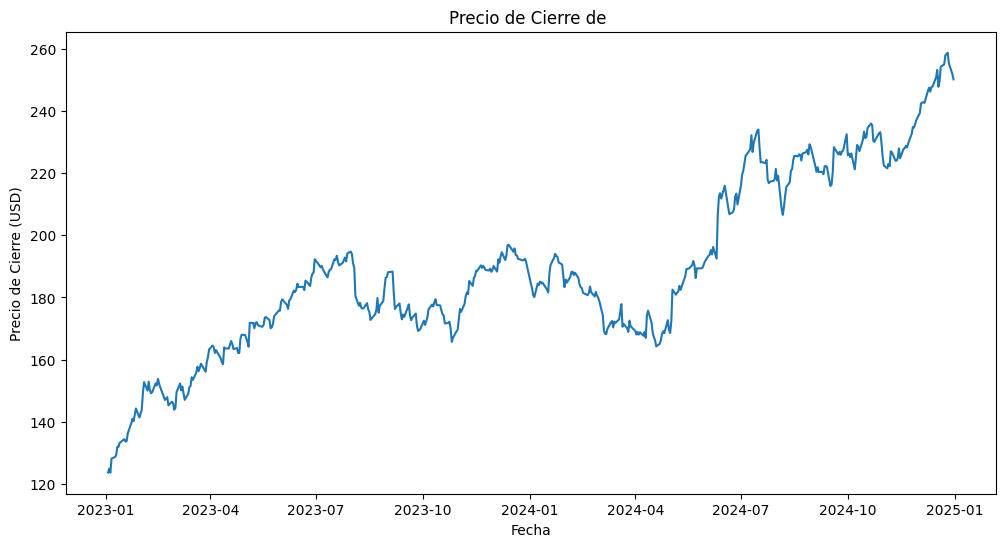

In [13]:
def analyze_data(data,symbol):
    """
    Analiza y muestra un resumen estadístico del conjunto de datos.
    """
    print("Primeras filas del dataset:")
    print(data.head())

    print(f"\nDescripción estadística: {symbol}")
    print(data.describe())

    plt.figure(figsize=(12, 6))
    plt.title('Precio de Cierre de ')
    plt.plot(data['close'])
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.show()

analyze_data(data,'Apple (AAPL)')

# NORMALIZAR Y CREAR SECUENCIAS

In [14]:
def normalize_data(data):
    """
    Normaliza los datos entre 0 y 1.
    """
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def create_sequences(data, sequence_length):
    """
    Crea secuencias de datos para la RNN con una longitud específica.
    """
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

In [15]:
# Preprocesamiento de los datos
close_data = data['close'].values.reshape(-1, 1)
print("Primeros 5 valores de close_data:")
print(close_data[:5])

scaled_data = normalize_data(close_data)
print("\nPrimeros 5 valores de scaled_data (normalizados):")
print(scaled_data[:5])

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)
print("\nForma de X e Y después de crear secuencias:")
print("X:", X.shape)
print("y:", y.shape)

# Convertir a tensores de PyTorch
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
print("\nTamaño de X después de convertir a tensores:")
print(X.size())
print("Tamaño de y después de convertir a tensores:")
print(y.size())

# Dividir los datos en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print("\nTamaño de X_train:", X_train.size())
print("Tamaño de y_train:", y_train.size())
print("Tamaño de X_test:", X_test.size())
print("Tamaño de y_test:", y_test.size())

Primeros 5 valores de close_data:
[[123.63252258]
 [124.90770721]
 [123.58309174]
 [128.13021851]
 [128.65414429]]

Primeros 5 valores de scaled_data (normalizados):
[[0.00036574]
 [0.0098009 ]
 [0.        ]
 [0.03364444]
 [0.03752099]]

Forma de X e Y después de crear secuencias:
X: (442, 60, 1)
y: (442, 1)

Tamaño de X después de convertir a tensores:
torch.Size([442, 60, 1])
Tamaño de y después de convertir a tensores:
torch.Size([442, 1])

Tamaño de X_train: torch.Size([353, 60, 1])
Tamaño de y_train: torch.Size([353, 1])
Tamaño de X_test: torch.Size([89, 60, 1])
Tamaño de y_test: torch.Size([89, 1])


# CREAMOS NUESTRO MODELO DE RNN CON LSTM CON PYTORCH

In [16]:
class StockPredictor(nn.Module):
  def __init__(self,input_size=1,hidden_layer_size=50,output_size=1):
    super(StockPredictor, self).__init__()
    self.hidden_layer_size = hidden_layer_size
    self.rnn = nn.RNN(input_size, hidden_layer_size, batch_first=True)
    self.linear = nn.Linear(hidden_layer_size, output_size)

  def forward(self, input_seq, hidden_cell):
    rnn_out, hidden_cell = self.rnn(input_seq, hidden_cell)
    predictions = self.linear(rnn_out[:, -1])
    return predictions, hidden_cell

  def init_hidden(self,batch_size):
    return torch.zeros(1,batch_size,self.hidden_layer_size)


# CONFIGURAMOS EL MODELO

In [17]:
model = StockPredictor()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# ENTRENAMOS NUESTRO MODELO

In [20]:

def train_model(model, X_train, y_train, epochs=25):
    """
    Entrena el modelo de RNN con los datos de entrenamiento.
    """
    for epoch in range(epochs):
      for idx in range(len(X_train)):
        seq = X_train[idx]
        label = X_train[idx]

        optimizer.zero_grad()

        # Inicializar el estado oculto para cada secuencia
        hidden_cell = model.init_hidden(1)

        y_pred, hidden_cell = model(seq.unsqueeze(0), hidden_cell)
        single_loss = loss_function(y_pred, label.unsqueeze(0))
        single_loss.backward()
        optimizer.step()
      print(f'Epoch {epoch}, Loss : {single_loss.item()}')

In [21]:
train_model(model, X_train, y_train, epochs=25)

Epoch 0, Loss : 0.007522200234234333
Epoch 1, Loss : 0.007414076942950487
Epoch 2, Loss : 0.007502441760152578
Epoch 3, Loss : 0.007505527697503567
Epoch 4, Loss : 0.0076661380007863045
Epoch 5, Loss : 0.008049425669014454
Epoch 6, Loss : 0.008493350818753242
Epoch 7, Loss : 0.008632165379822254
Epoch 8, Loss : 0.008569872006773949
Epoch 9, Loss : 0.00846157968044281
Epoch 10, Loss : 0.00842705275863409
Epoch 11, Loss : 0.008345549926161766
Epoch 12, Loss : 0.008342982269823551
Epoch 13, Loss : 0.008146182633936405
Epoch 14, Loss : 0.008227918297052383
Epoch 15, Loss : 0.008097255602478981
Epoch 16, Loss : 0.007986347191035748
Epoch 17, Loss : 0.0079795615747571
Epoch 18, Loss : 0.007940643467009068
Epoch 19, Loss : 0.007882636971771717
Epoch 20, Loss : 0.008319016546010971
Epoch 21, Loss : 0.008067047223448753
Epoch 22, Loss : 0.008069191128015518
Epoch 23, Loss : 0.008139681071043015
Epoch 24, Loss : 0.007431340403854847


# EVALUAMOS EL MODELO

In [22]:
def evaluate_model(model, X_test, y_test):
    """
    Evalúa el modelo y realiza predicciones sobre los datos de prueba.
    """
    model.eval()
    predictions = []
    for seq in X_test:
        with torch.no_grad():
            hidden_cell = model.init_hidden(1)

            y_pred, hidden_cell = model(seq.unsqueeze(0), hidden_cell)
            predictions.append(y_pred.item())

    predictions = np.array(predictions).reshape(-1, 1)
    predictions = predictions * (np.max(close_data) - np.min(close_data)) + np.min(close_data)

    # Calcular el RMSE
    rmse = np.sqrt(np.mean((predictions - (y_test.numpy() * (np.max(close_data) - np.min(close_data)) + np.min(close_data)))**2))
    print(f'Root Mean Squared Error: {rmse}')

    return predictions

In [23]:
predictions = evaluate_model(model, X_test, y_test)

Root Mean Squared Error: 13.826894208004815


# VISUALIZAMOS RESULTADOS

<ipython-input-25-25e4308b41b9>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


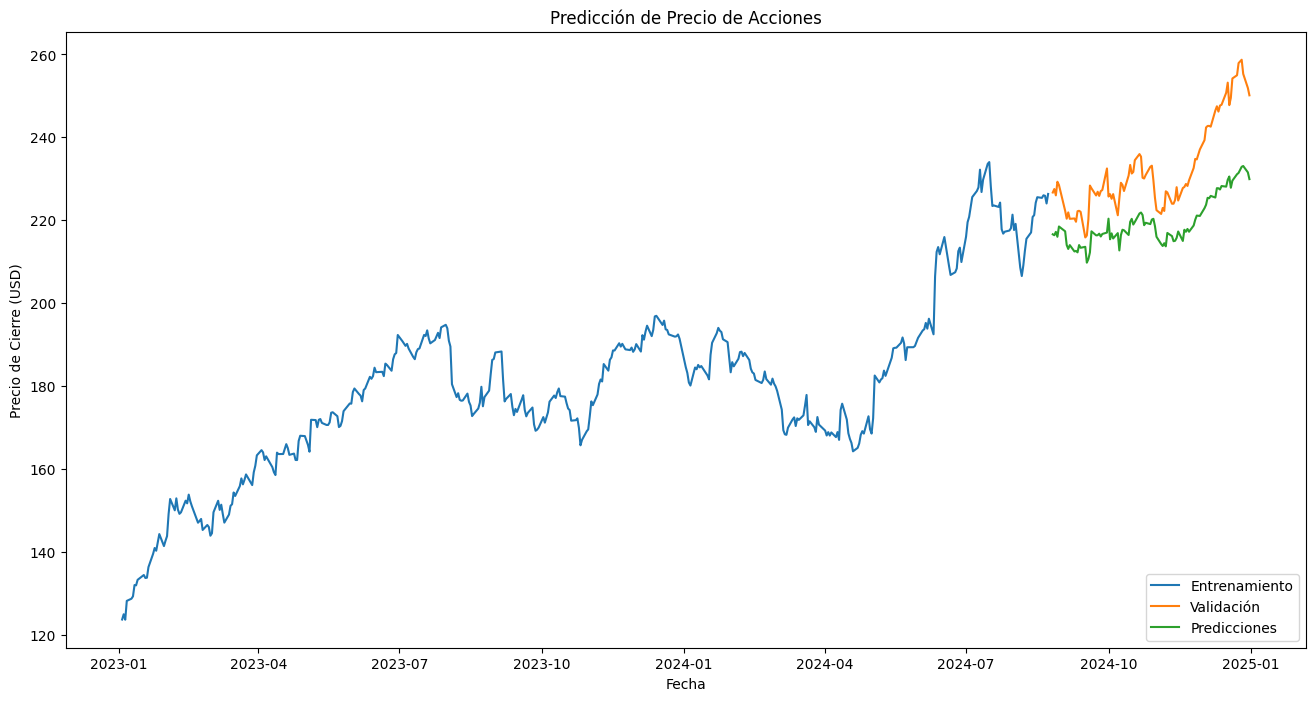

                 close  Predictions
Date                               
2024-12-24  257.916443   231.416758
2024-12-26  258.735504   232.895118
2024-12-27  255.309296   233.084717
2024-12-30  251.923019   231.552811
2024-12-31  250.144974   229.917404


In [25]:
def plot_results(data, train_size, predictions):
    """
    Visualiza los resultados de las predicciones frente a los valores reales.
    """
    train = data[:train_size + sequence_length]
    valid = data[train_size + sequence_length:]
    valid['Predictions'] = predictions

    plt.figure(figsize=(16, 8))
    plt.title('Predicción de Precio de Acciones')
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.plot(train['close'])
    plt.plot(valid[['close', 'Predictions']])
    plt.legend(['Entrenamiento', 'Validación', 'Predicciones'], loc='lower right')
    plt.show()

    print(valid[['close', 'Predictions']].tail())

# Visualización de los resultados
plot_results(data, train_size, predictions)

# PREDECIMOS VALORES PARA X_TEST

In [26]:
def predict_manual(model, X_test):
    """
    Realiza una predicción manual del siguiente valor de la secuencia.
    """
    model.eval()
    with torch.no_grad():
        new_sequence = X_test[-1].unsqueeze(0)

        hidden_cell = model.init_hidden(1)

        # Realizar la predicción con el estado oculto
        predicted_price, hidden_cell = model(new_sequence, hidden_cell)
        predicted_price = predicted_price.item() * (np.max(close_data) - np.min(close_data)) + np.min(close_data)

    print(f'Predicción manual del próximo precio de cierre: {predicted_price} USD')

In [27]:
# Predicción manual
predict_manual(model, X_test)

Predicción manual del próximo precio de cierre: 229.91740449957888 USD
